[i] Превью данных:
                   ds        y
0 2020-03-09 12:34:37  24.9122
1 2020-03-09 12:34:38  24.9038
2 2020-03-09 12:34:39  24.9055
3 2020-03-09 12:34:40  24.9110
4 2020-03-09 12:34:41  24.9110


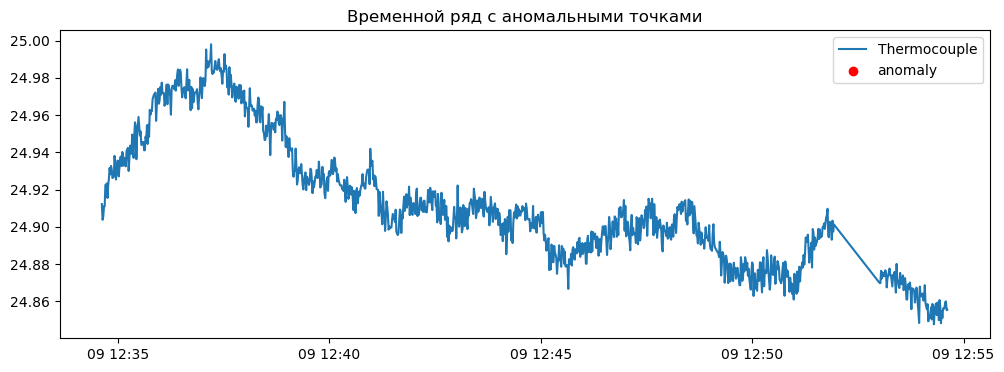

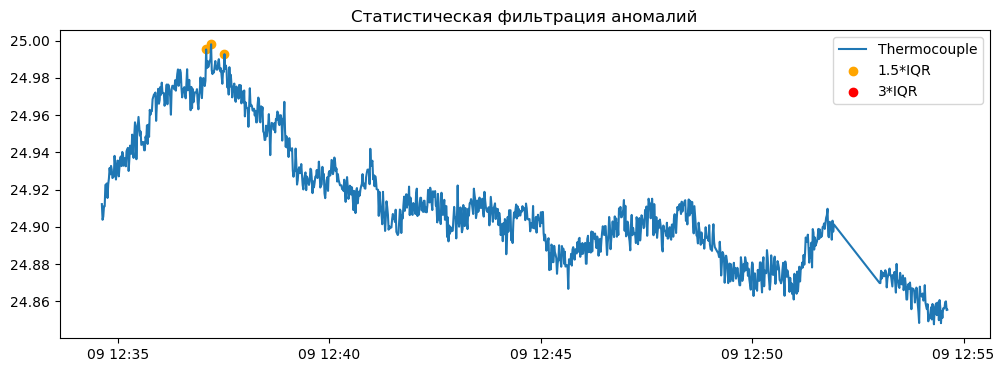

[i] Confusion matrix (stat 1.5*IQR):
[[1091    3]
 [   0    0]]


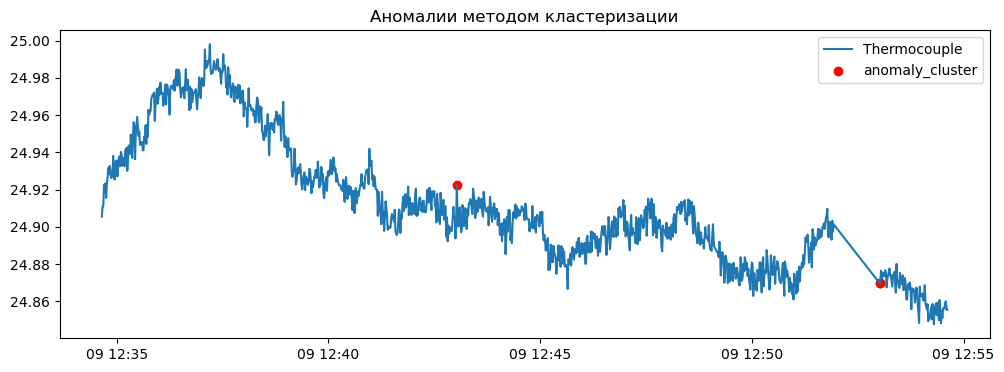

[i] Confusion matrix (cluster):
[[1089    3]
 [   0    0]]


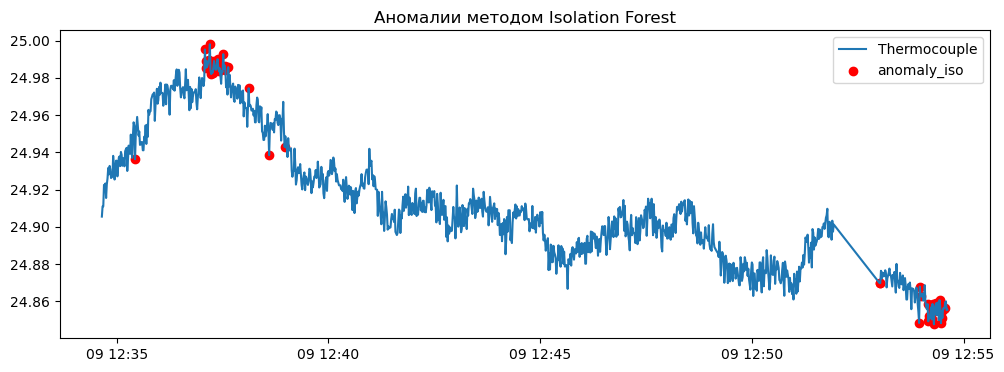

[i] Confusion matrix (Isolation Forest):
[[1037   55]
 [   0    0]]

[Итоговая сводка по методам]:
            method  anomalies_detected
0      stat_1.5IQR                   3
1        stat_3IQR                   0
2   cluster_DBSCAN                   3
3  IsolationForest                  55


In [1]:
# Конев Юрий Денисович, РИ-421002
# Homewor3. 

import os
import csv
import random
import warnings
from typing import Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.ensemble import IsolationForest
from sklearn.metrics import confusion_matrix

# --------------- Конфигурация ---------------
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (12, 4)

# Путь к CSV
DATA_PATH = r"C:\Users\sl1ober\Desktop\me\skab_valve_1.csv"

# --------------- Вспомогательные функции ---------------
def safe_to_numeric(s: pd.Series) -> pd.Series:
    """Привести серию к числу, заменяя запятую на точку и убирая пробелы."""
    return pd.to_numeric(s.astype(str).str.replace(',', '.').str.strip(), errors='coerce')

def infer_and_read_csv(path: str) -> pd.DataFrame:
    """Прочитать CSV с авто-подбором разделителя."""
    if not os.path.exists(path):
        raise FileNotFoundError(f"Файл не найден: {path}")

    # Попытка авто-определения разделителя
    sample = ""
    with open(path, 'r', encoding='utf-8', errors='ignore') as f:
        for _ in range(10):
            try:
                sample += next(f)
            except StopIteration:
                break
    try:
        dialect = csv.Sniffer().sniff(sample, delimiters=[',', ';', '\t', '|'])
        sep = dialect.delimiter
    except Exception:
        sep = ';'  # fallback
    df = pd.read_csv(path, sep=sep, encoding='utf-8', engine='python')

    if df.shape[1] == 1:
        # распарсим вручную split
        s = df.iloc[:, 0].astype(str)
        splitted = s.str.split(sep, expand=True)
        df = splitted
        df.columns = [f"c{i}" for i in range(df.shape[1])]
    return df

def detect_columns(df: pd.DataFrame):
    """Найти колонку с термопарой и колонку с датой."""
    col_names = [str(c) for c in df.columns]
    value_col = None
    date_col = None

    for c in col_names:
        if 'thermocouple' in c.lower():
            value_col = c
        s = df[c].astype(str).head(100)
        if s.str.contains(r"\d{4}-\d{2}-\d{2}").any() or s.str.contains(r"\d{2}:\d{2}:\d{2}").any():
            date_col = c
    if value_col is None:
        # fallback: выбрать первую числовую колонку
        numeric_cols = []
        for c in col_names:
            sample = df[c].dropna().astype(str).str.replace(',', '.').str.strip()
            converted = pd.to_numeric(sample, errors='coerce')
            if converted.notna().sum() >= max(5, len(sample)//2):
                numeric_cols.append(c)
        if numeric_cols:
            value_col = numeric_cols[0]
    return value_col, date_col

# --------------- Загрузка и предобработка ---------------
df_raw = infer_and_read_csv(DATA_PATH)
value_col, date_col = detect_columns(df_raw)

df = df_raw.copy()
if date_col is not None:
    df['ds'] = pd.to_datetime(df[date_col].astype(str).str.replace(';', ' '), errors='coerce')
else:
    df['ds'] = pd.RangeIndex(start=0, stop=len(df))

df['y'] = safe_to_numeric(df[value_col])
df = df.dropna(subset=['y']).reset_index(drop=True)
df = df.sort_values('ds').reset_index(drop=True)

print("[i] Превью данных:")
print(df[['ds', 'y']].head())

# --------------- Визуализация ряда с аномальными точками ---------------
df['anomaly'] = 0  # пометка аномалий
plt.figure()
plt.plot(df['ds'], df['y'], label='Thermocouple')
plt.scatter(df.loc[df['anomaly']==1, 'ds'], df.loc[df['anomaly']==1, 'y'], color='red', label='anomaly')
plt.title("Временной ряд с аномальными точками")
plt.legend()
plt.show()

# --------------- Статистическая фильтрация аномалий ---------------
Q1 = df['y'].quantile(0.25)
Q3 = df['y'].quantile(0.75)
IQR = Q3 - Q1

# Лёгкая фильтрация
lower1 = Q1 - 1.5 * IQR
upper1 = Q3 + 1.5 * IQR
df['anomaly_stat_1.5'] = ((df['y'] < lower1) | (df['y'] > upper1)).astype(int)

# Жёсткая фильтрация
lower3 = Q1 - 3 * IQR
upper3 = Q3 + 3 * IQR
df['anomaly_stat_3'] = ((df['y'] < lower3) | (df['y'] > upper3)).astype(int)

# Визуализация статистических аномалий
plt.figure()
plt.plot(df['ds'], df['y'], label='Thermocouple')
plt.scatter(df.loc[df['anomaly_stat_1.5']==1, 'ds'], df.loc[df['anomaly_stat_1.5']==1, 'y'], color='orange', label='1.5*IQR')
plt.scatter(df.loc[df['anomaly_stat_3']==1, 'ds'], df.loc[df['anomaly_stat_3']==1, 'y'], color='red', label='3*IQR')
plt.title("Статистическая фильтрация аномалий")
plt.legend()
plt.show()

# Confusion matrix для статистики 1.5*IQR
# Для демонстрации использую случайную генерацию true labels
true_labels = df['anomaly'].values
pred_labels = df['anomaly_stat_1.5'].values
cm = confusion_matrix(true_labels, pred_labels)
print("[i] Confusion matrix (stat 1.5*IQR):")
print(cm)

# --------------- Feature-Engineering для кластеризации ---------------
fe = df.copy()
fe['lag1'] = fe['y'].shift(1)
fe['lag2'] = fe['y'].shift(2)
fe['roll_mean3'] = fe['y'].rolling(3).mean()
fe['roll_std3'] = fe['y'].rolling(3).std()
fe['hour'] = fe['ds'].dt.hour
fe['weekday'] = fe['ds'].dt.weekday
fe = fe.dropna().reset_index(drop=True)

X_cluster = fe[['y','lag1','lag2','roll_mean3','roll_std3','hour','weekday']]

# --------------- Кластеризация (DBSCAN) ---------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

db = DBSCAN(eps=1.5, min_samples=5)
fe['anomaly_cluster'] = db.fit_predict(X_scaled)
# DBSCAN метка -1 => аномалия
fe['anomaly_cluster'] = (fe['anomaly_cluster']==-1).astype(int)

plt.figure()
plt.plot(fe['ds'], fe['y'], label='Thermocouple')
plt.scatter(fe.loc[fe['anomaly_cluster']==1, 'ds'], fe.loc[fe['anomaly_cluster']==1, 'y'], color='red', label='anomaly_cluster')
plt.title("Аномалии методом кластеризации")
plt.legend()
plt.show()

cm_cluster = confusion_matrix(fe['anomaly'].values[-len(fe):], fe['anomaly_cluster'].values)
print("[i] Confusion matrix (cluster):")
print(cm_cluster)

# --------------- Isolation Forest ---------------
iso = IsolationForest(contamination=0.05, random_state=RANDOM_STATE)
fe['anomaly_iso'] = iso.fit_predict(X_scaled)
# -1 => аномалия
fe['anomaly_iso'] = (fe['anomaly_iso']==-1).astype(int)

plt.figure()
plt.plot(fe['ds'], fe['y'], label='Thermocouple')
plt.scatter(fe.loc[fe['anomaly_iso']==1, 'ds'], fe.loc[fe['anomaly_iso']==1, 'y'], color='red', label='anomaly_iso')
plt.title("Аномалии методом Isolation Forest")
plt.legend()
plt.show()

cm_iso = confusion_matrix(fe['anomaly'].values[-len(fe):], fe['anomaly_iso'].values)
print("[i] Confusion matrix (Isolation Forest):")
print(cm_iso)

# --------------- Сбор агрегированных результатов ---------------
results_summary = pd.DataFrame({
    'method':['stat_1.5IQR','stat_3IQR','cluster_DBSCAN','IsolationForest'],
    'anomalies_detected':[df['anomaly_stat_1.5'].sum(), df['anomaly_stat_3'].sum(), fe['anomaly_cluster'].sum(), fe['anomaly_iso'].sum()]
})

print("\n[Итоговая сводка по методам]:")
print(results_summary)
results_summary.to_csv("anomaly_detection_summary.csv", index=False)
